# PyTorch (continued)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## XOR Dataset Classification

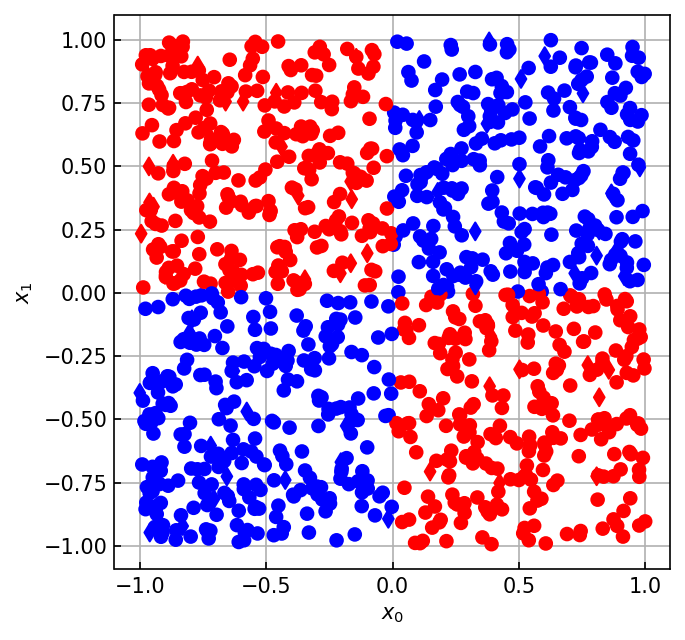

In [6]:
def make_xor_dataset(N=100, random_seed=42):
    np.random.seed(random_seed)
    X = np.random.uniform(size=(N, 2)).astype(np.float32)
    X = 2 * X - 1.
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    y = np.where(y, 1, 0)
    return X, y

X, y = make_xor_dataset(N=1024, random_seed=42)
X_test, y_test = make_xor_dataset(N=64, random_seed=1)

ax = plt.figure().gca()
ax.scatter(X[:, 0], X[:, 1], c=y, marker='o', cmap='bwr')
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='d', cmap='bwr')
ax.set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal');

In [7]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
train_dataset, val_dataset = random_split(dataset, (0.8, 0.2))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)

Train: 820, Val: 204, Test: 64


### Training script (for an arbitrary model)

In [46]:
from tqdm import tqdm, trange

def train(model, loss_fn, optimizer, train_dataset, val_dataset, 
          batch_size=32, max_epochs=100, num_workers=0):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    # Create dataloaders for train/validation
    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    
    pbar_epoch = trange(max_epochs)
    for ii in pbar_epoch:
        train_loss_ = 0.
        train_acc_ = 0.
        for x, y, in train_loader:
            # Send x, y to GPU/TPU/etc.
            x = x.to(device)
            y = y.to(device)

            # Make a prediction, compute the loss
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

            # Backpropagate gradients, apply weight updates, reset gradients
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Logging
            train_loss_ += loss.item() * x.shape[0]
            train_acc_  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

        train_loss.append(train_loss_ / len(train_dataset))
        train_acc.append(train_acc_ / len(train_dataset))

        val_loss_ = 0.
        val_acc_ = 0.
        with torch.no_grad():
            for x, y, in val_loader:
                # Send x, y to GPU/TPU/etc.
                x = x.to(device)
                y = y.to(device)
    
                # Make a prediction, compute the loss
                y_pred = model(x)
                loss = loss_fn(y_pred, y)
        
                # Logging
                val_loss_ += loss.item() * x.shape[0]
                val_acc_  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

            val_loss.append(val_loss_ / len(val_dataset))
            val_acc.append(val_acc_ / len(val_dataset))

        pbar_epoch.set_postfix(
            epoch=f"{ii+1:03d} / {max_epochs:03d}",
            train_loss=f"{train_loss[-1]:.3f}",
            train_acc=f"{train_acc[-1]:.3f}",
            val_loss=f"{val_loss[-1]:.3f}",
            val_acc=f"{val_acc[-1]:.3f}")

    return model, (train_loss, train_acc, val_loss, val_acc)

### Model creation and training

In [16]:
def loss_accuracy_plot(train_loss, train_acc, val_loss, val_acc):
    fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

    ax[0].plot(train_loss, color='black', label='Train')
    ax[0].plot(val_loss, color='red', label='Validation')
    ax[0].set(xlabel='Epoch', ylabel='Cross Entropy Loss', yscale='log')

    ax[1].plot(train_acc, color='black', label='Train')
    ax[1].plot(val_acc, color='red', label='Validation')
    ax[1].set(xlabel='Epoch', ylabel='Accuracy')

    fig.legend(*ax[1].get_legend_handles_labels(), 
            loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)
    return fig

from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red']):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    with torch.no_grad():
        x_grid = np.stack([x1.ravel(), x2.ravel()]).T
        x_grid = torch.from_numpy(x_grid.astype(np.float32)).to(device)
        y_model = model(x_grid).cpu().numpy()
        y_model = np.argmax(y_model, axis=-1)
        y_model = y_model.reshape(x1.shape)

        y_pred = model(torch.from_numpy(X).to(device)).cpu().numpy()
        y_pred = np.argmax(y_pred, axis=1)

        pred_mask = y_pred == y

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        label_mask = y == label
        ax.scatter(X[label_mask & pred_mask, 0], X[label_mask & pred_mask, 1], 
                   facecolor=colors[label], edgecolor=colors[label])
        ax.scatter(X[label_mask & ~pred_mask, 0], X[label_mask & ~pred_mask, 1], 
                   facecolor='white', edgecolor=colors[label])
    return ax

In [17]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Softmax(),
).to(device)

loss_fn = nn.CrossEntropyLoss() # Binary cross entropy
optimizer = torch.optim.SGD(model.parameters(), lr=5e-2)
model, model_stats = train(model, loss_fn, optimizer, train_dataset, val_dataset)

100%|██████████| 100/100 [00:02<00:00, 38.94it/s, epoch=100 / 100, train_acc=0.460, train_loss=0.692, val_acc=0.426, val_loss=0.692]


<Axes: >

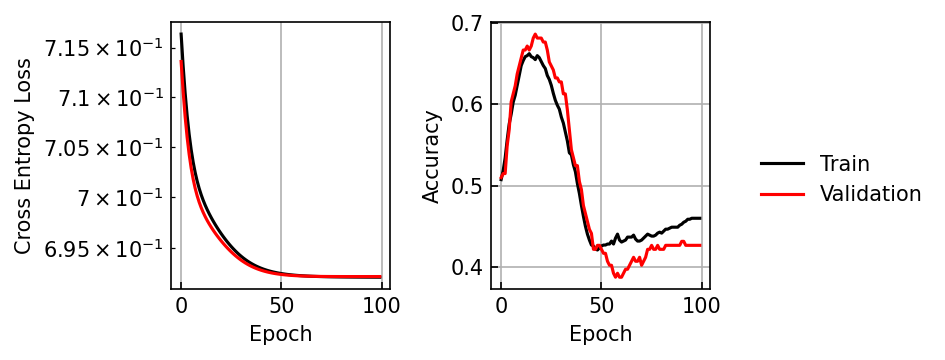

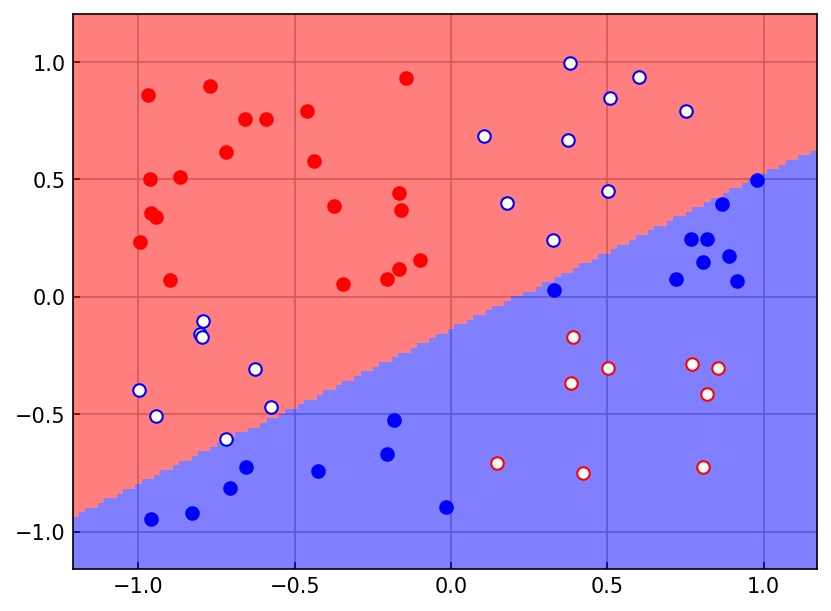

In [18]:
loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

100%|██████████| 100/100 [00:03<00:00, 32.53it/s, epoch=100 / 100, train_acc=0.995, train_loss=0.035, val_acc=0.985, val_loss=0.060]


<Axes: >

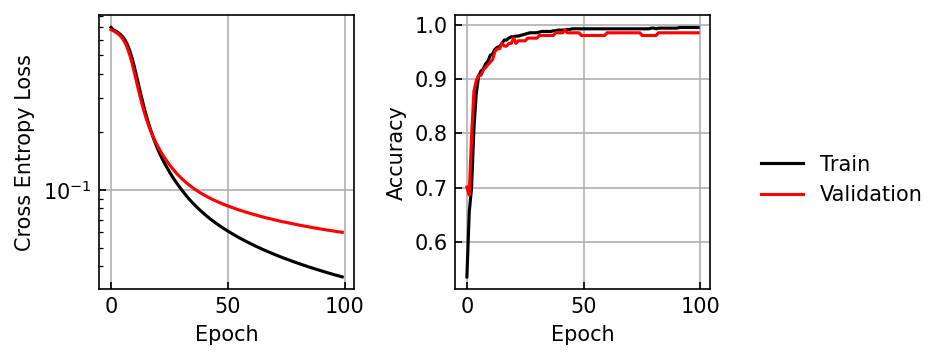

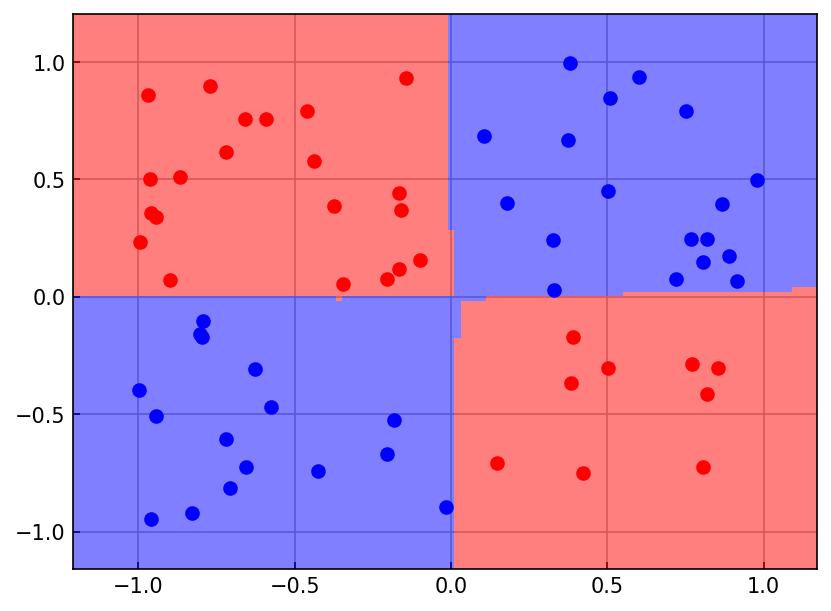

In [19]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2),
).to(device)

loss_fn = nn.CrossEntropyLoss() # cross entropy
optimizer = torch.optim.SGD(model.parameters(), lr=5e-2)
model, model_stats= train(model, loss_fn, optimizer, train_dataset, val_dataset)
loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

## Customizing model behavior

In [31]:
class NoisyLinear(nn.Module):
    """ Layers also extend nn.Module """
    def __init__(self, input_size, output_size, noise_std=0.05):
        super().__init__()
        self.w = nn.Parameter(
            torch.FloatTensor(input_size, output_size)
        )
        nn.init.xavier_uniform_(self.w)

        self.b = nn.Parameter(
            torch.FloatTensor(output_size,).fill_(0)
        )

        self.noise_std = noise_std

    def forward(self, x, training=False):
        if training:
            x_new = x + torch.normal(0., self.noise_std, size=x.shape, device=x.device)
        else:
            x_new = x

        return x_new @ self.w + self.b

class NoisyModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=16, output_size=2, noise_std=0.05):
        super().__init__()
        self.hidden_layer1 = NoisyLinear(input_size, hidden_size, noise_std=noise_std)
        self.hidden_layer2 = torch.nn.Linear(hidden_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x, training=False):
        x = self.hidden_layer1(x, training=training)
        x = torch.nn.functional.relu(x)
        x = self.hidden_layer2(x)
        x = torch.nn.functional.relu(x)
        x = self.output_layer(x)
        return x

model = NoisyModel().to(device)
model

NoisyModel(
  (hidden_layer1): NoisyLinear()
  (hidden_layer2): Linear(in_features=16, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=2, bias=True)
)

100%|██████████| 200/200 [00:06<00:00, 32.16it/s, epoch=200 / 200, train_acc=0.995, train_loss=0.020, val_acc=0.980, val_loss=0.050]


<Axes: >

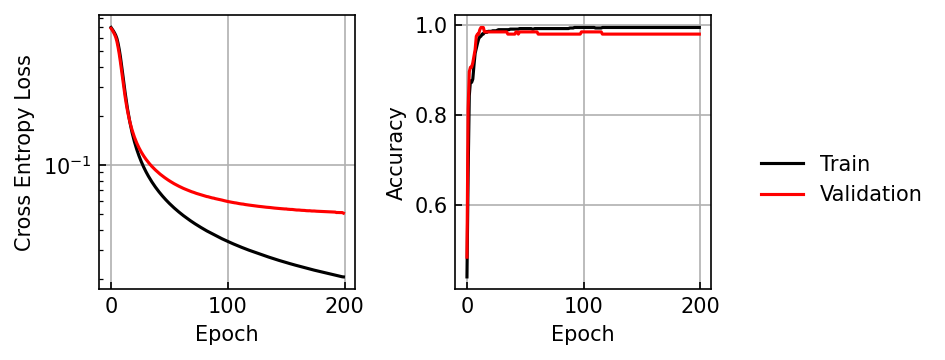

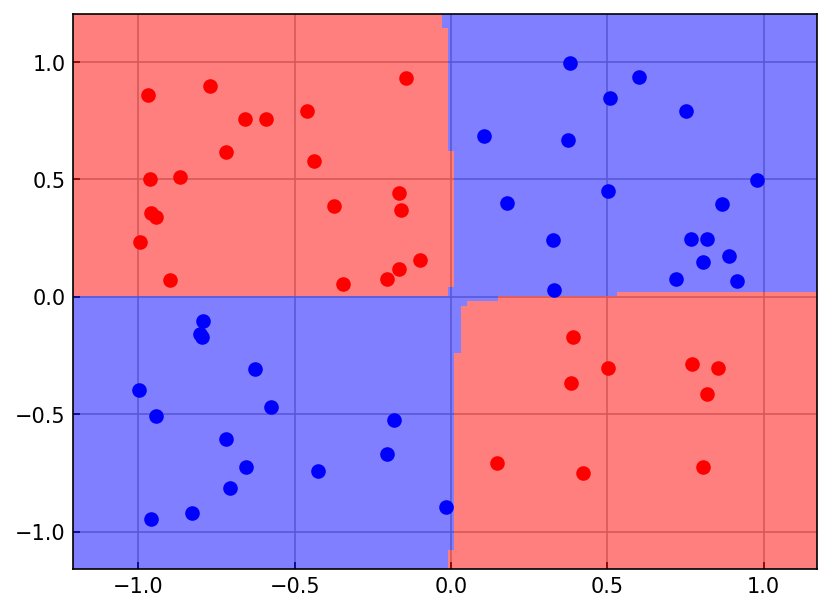

In [32]:
model = NoisyModel(noise_std=0.1).to(device)
loss_fn = nn.CrossEntropyLoss() # cross entropy
optimizer = torch.optim.SGD(model.parameters(), lr=5e-2)

model, model_stats= train(model, loss_fn, optimizer, train_dataset, val_dataset, max_epochs=200)
loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

## MNIST Classification

In [54]:
import torchvision
from torchvision.transforms import v2

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
train_val_ds = torchvision.datasets.MNIST(
    root='~/scr10',
    train=True,
    transform=transform,
    download=True
)

test_ds = torchvision.datasets.MNIST(
    root='~/scr10',
    train=False,
    transform=transform,
    download=False
)

In [55]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(train_ds[0][0].numel(), 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)
model = model.to(device)


model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=10, bias=True)
)

### Adam optimizer

The Adam, or **adaptive momentum** optimizer, makes use of two minimal extensions to stochastic gradient descent:

- adaptive learning rate
- momentum

100%|██████████| 10/10 [00:43<00:00,  4.32s/it, epoch=010 / 010, train_acc=0.950, train_loss=0.168, val_acc=0.949, val_loss=0.178]


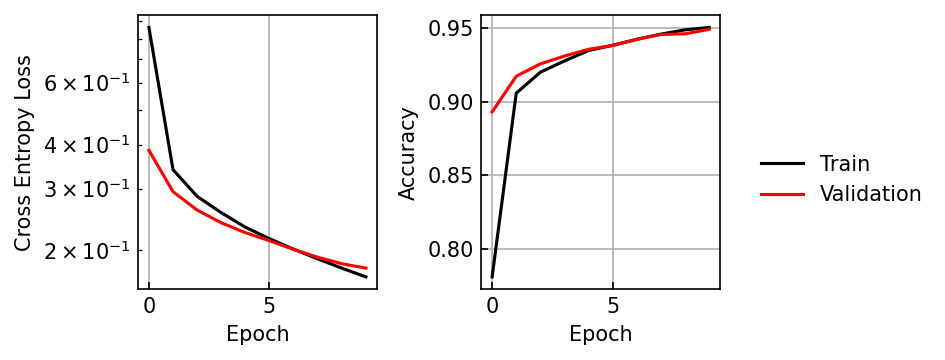

In [56]:
loss_fn = nn.CrossEntropyLoss() # cross entropy
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

train_dataset, val_dataset = random_split(train_val_ds, lengths=[0.8, 0.2])

model, model_stats= train(model, loss_fn, optimizer, train_dataset, val_dataset, 
                          batch_size=64, num_workers=4, max_epochs=10)
loss_accuracy_plot(*model_stats)
plt.tight_layout()

In [57]:
# Inference
model.eval()
test_loader = DataLoader(test_ds, batch_size=64, num_workers=4, shuffle=False)
with torch.no_grad():
    test_correct_ = 0.
    for xb, yb in tqdm(test_loader,leave=False):
        xb = xb.to(device)
        yb = yb.to(device)
        y_pred = model(xb)
        y_pred = torch.argmax(y_pred, dim=1)
        test_correct_ += (y_pred == yb).float().sum().item()
    test_acc = test_correct_ / len(test_loader.dataset)

print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.947


### Learning rate schedulers

In [63]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(train_ds[0][0].numel(), 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)
model = model.to(device)


100%|██████████| 10/10 [00:42<00:00,  4.23s/it, epoch=010 / 010, lr=0.0417, train_acc=0.965, train_loss=0.121, val_acc=0.960, val_loss=0.136]


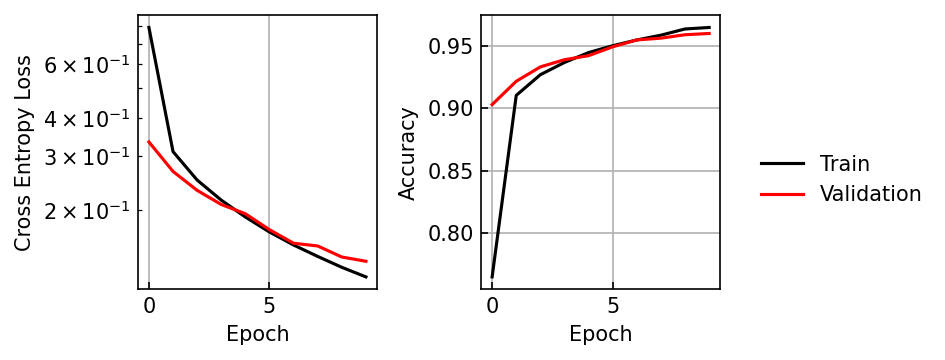

In [64]:
from tqdm import tqdm, trange

def train_scheduler(model, loss_fn, optimizer, scheduler, train_dataset, val_dataset, 
                    batch_size=32, max_epochs=100, num_workers=0, device=device):
    # Send model to correct hardware device
    model = model.to(device)

    # Create dataloaders for train/validation
    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    

    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    pbar_epoch = trange(max_epochs)
    for ii in pbar_epoch:
        train_loss_ = 0.
        train_acc_ = 0.
        for x, y, in train_loader:
            # Send x, y to GPU/TPU/etc.
            x = x.to(device)
            y = y.to(device)

            # Make a prediction, compute the loss
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

            # Backpropagate gradients, apply weight updates, reset gradients
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Logging
            train_loss_ += loss.item() * x.shape[0]
            train_acc_  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

        train_loss.append(train_loss_ / len(train_dataset))
        train_acc.append(train_acc_ / len(train_dataset))

        val_loss_ = 0.
        val_acc_ = 0.
        with torch.no_grad():
            for x, y, in val_loader:
                # Send x, y to GPU/TPU/etc.
                x = x.to(device)
                y = y.to(device)
    
                # Make a prediction, compute the loss
                y_pred = model(x)
                loss = loss_fn(y_pred, y)
        
                # Logging
                val_loss_ += loss.item() * x.shape[0]
                val_acc_  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

            val_loss.append(val_loss_ / len(val_dataset))
            val_acc.append(val_acc_ / len(val_dataset))
            
        pbar_epoch.set_postfix(
            epoch=f"{ii+1:03d} / {max_epochs:03d}",
            lr=f"{optimizer.param_groups[0]['lr']:.3g}",
            train_loss=f"{train_loss[-1]:.3f}",
            train_acc=f"{train_acc[-1]:.3f}",
            val_loss=f"{val_loss[-1]:.3f}",
            val_acc=f"{val_acc[-1]:.3f}")

        scheduler.step()

    return model, (train_loss, train_acc, val_loss, val_acc)

loss_fn = nn.CrossEntropyLoss() # cross entropy
optimizer = torch.optim.SGD(model.parameters(), lr=5e-2)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98) # Decay learning rate by factor

model, model_stats= train_scheduler(model, loss_fn, optimizer, scheduler, train_dataset, val_dataset, 
                                    batch_size=64, num_workers=4, max_epochs=10)
loss_accuracy_plot(*model_stats)
plt.tight_layout()

In [65]:
# Inference
model.eval()
test_loader = DataLoader(test_ds, batch_size=64, num_workers=4, shuffle=False)
with torch.no_grad():
    test_correct_ = 0.
    for xb, yb in tqdm(test_loader,leave=False):
        xb = xb.to(device)
        yb = yb.to(device)
        y_pred = model(xb)
        y_pred = torch.argmax(y_pred, dim=1)
        test_correct_ += (y_pred == yb).float().sum().item()
    test_acc = test_correct_ / len(test_loader.dataset)

print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.960
